In [99]:
import pandas as pd
import matplotlib.pyplot as plt

from etl.load import create_db_engine

import os
from dotenv import load_dotenv

In [100]:
load_dotenv(override=True)

True

### Connect to MySQL

In [101]:
DB_USER = os.getenv("DB_USER")
DB_PASSWORD = os.getenv("DB_PASSWORD")
DB_HOST = os.getenv("DB_HOST")
DB_PORT = os.getenv("DB_PORT")
DB_NAME = os.getenv("DB_NAME")

In [102]:
engine = create_db_engine(
    DB_USER,
    DB_PASSWORD,
    DB_HOST,
    DB_PORT,
    DB_NAME
)

### Get the data from `jobs` table

In [103]:
df = pd.read_sql("SELECT * FROM jobs", engine)

In [104]:
print(f"Loaded {len(df)} rows from MySQL")
df.head(2)

Loaded 2209 rows from MySQL


,created_date,job_title,company,salary,address,time,link_description,min_salary,max_salary,salary_unit,job_group,city,district
0,2023-08-01,Business Analyst,Công ty TNHH Công nghệ số Adamo,10 - 20 triệu,Hà Nội,Còn 25 ngày để ứng tuyển,https://www.topcv.vn/viec-lam/business-analyst...,10000000.0,20000000.0,VND,Business Analyst,Hà Nội,None
1,2023-08-01,Nhân Viên Lập Trình Phần Mềm - Thu Nhập Từ 10 ...,Công ty TNHH Đầu Tư Công Nghệ ST,10 - 20 triệu,Hồ Chí Minh,Còn 91 ngày để ứng tuyển,https://www.topcv.vn/viec-lam/nhan-vien-lap-tr...,10000000.0,20000000.0,VND,Software Developer,Hồ Chí Minh,None


In [105]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2209 entries, 0 to 2208
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   created_date      2209 non-null   object 
 1   job_title         2209 non-null   object 
 2   company           2209 non-null   object 
 3   salary            2209 non-null   object 
 4   address           2209 non-null   object 
 5   time              2209 non-null   object 
 6   link_description  2209 non-null   object 
 7   min_salary        766 non-null    float64
 8   max_salary        1212 non-null   float64
 9   salary_unit       1347 non-null   object 
 10  job_group         2209 non-null   object 
 11  city              2209 non-null   object 
 12  district          1868 non-null   object 
dtypes: float64(2), object(11)
memory usage: 224.5+ KB


### Analysis 1: Salary distribution by job position

In [106]:
salary_df = df[df["min_salary"].notna() & df["max_salary"].notna()].copy()
salary_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 631 entries, 0 to 2200
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   created_date      631 non-null    object 
 1   job_title         631 non-null    object 
 2   company           631 non-null    object 
 3   salary            631 non-null    object 
 4   address           631 non-null    object 
 5   time              631 non-null    object 
 6   link_description  631 non-null    object 
 7   min_salary        631 non-null    float64
 8   max_salary        631 non-null    float64
 9   salary_unit       631 non-null    object 
 10  job_group         631 non-null    object 
 11  city              631 non-null    object 
 12  district          563 non-null    object 
dtypes: float64(2), object(11)
memory usage: 69.0+ KB


In [107]:
salary_df["avg_salary"] = (salary_df["min_salary"] + salary_df["max_salary"]) / 2

#### VND only

In [108]:
salary_df.columns

Index(['created_date', 'job_title', 'company', 'salary', 'address', 'time',
       'link_description', 'min_salary', 'max_salary', 'salary_unit',
       'job_group', 'city', 'district', 'avg_salary'],
      dtype='object')

In [109]:
vnd_salary_df = salary_df[salary_df["salary_unit"] == "VND"].copy()
vnd_salary_df["avg_salary_million"] = (vnd_salary_df["avg_salary"] / 1_000_000)
usd_salary_df = salary_df[salary_df["salary_unit"] == "USD"].copy()

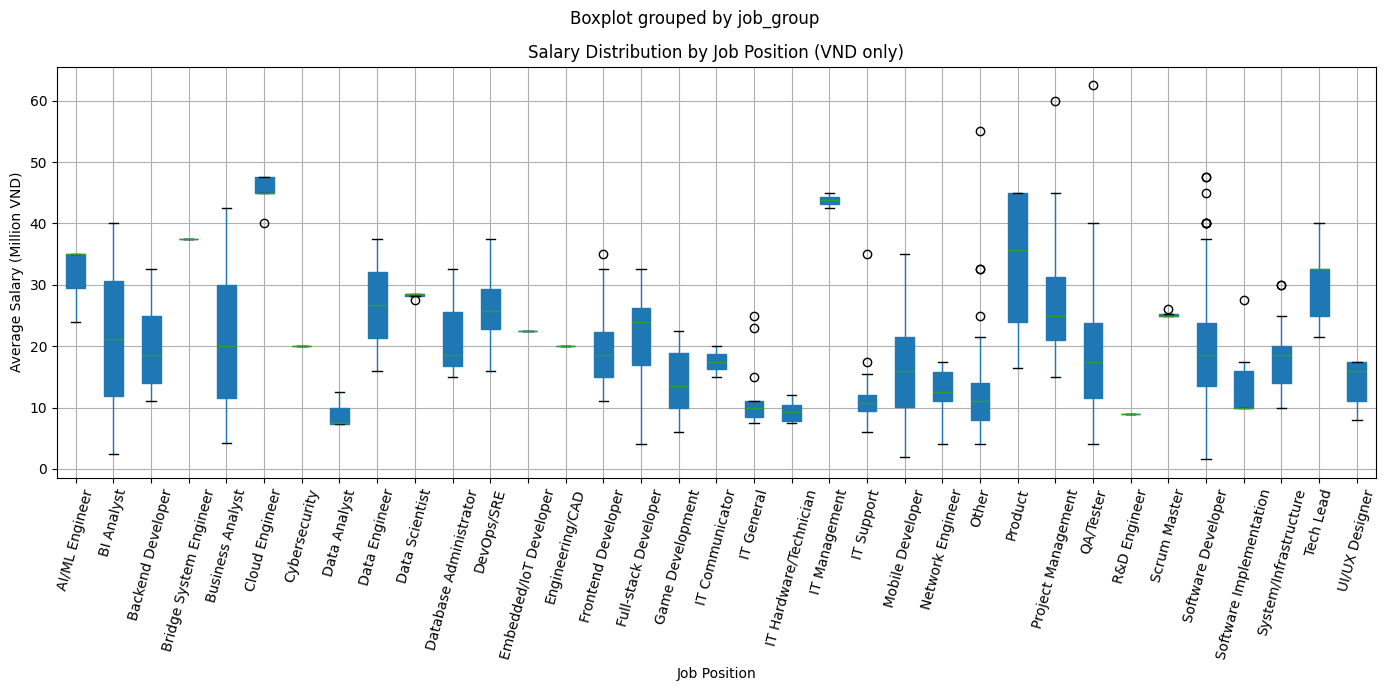

In [110]:
vnd_salary_df.boxplot(column="avg_salary_million", by="job_group", rot=75, figsize=(14,7), patch_artist=True)
plt.title("Salary Distribution by Job Position (VND only)")
plt.xlabel("Job Position")
plt.ylabel("Average Salary (Million VND)")
plt.tight_layout()
plt.show()

#### USD only

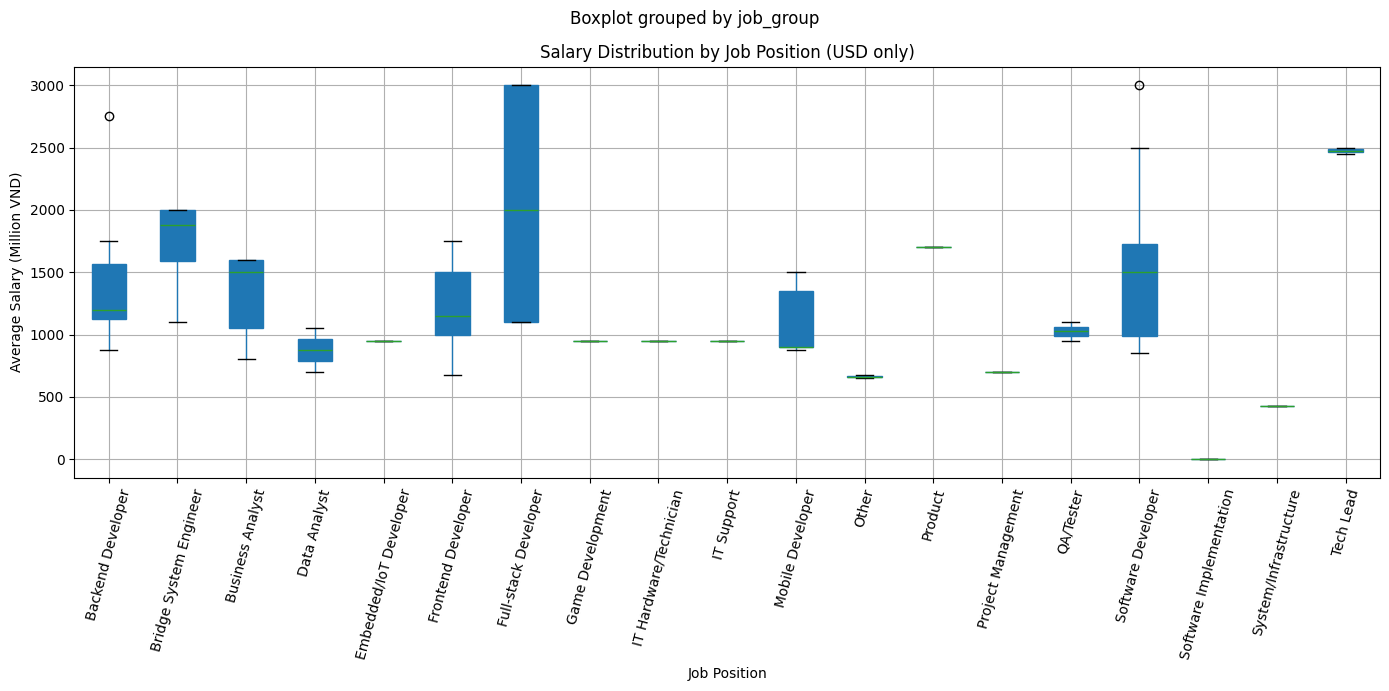

In [111]:
usd_salary_df.boxplot(column="avg_salary", by="job_group", rot=75, figsize=(14,7), patch_artist=True)
plt.title("Salary Distribution by Job Position (USD only)")
plt.xlabel("Job Position")
plt.ylabel("Average Salary (Million VND)")
plt.tight_layout()
plt.show()

#### USD & VND combined

In [112]:
combined_salary_df = salary_df.copy()
combined_salary_df["avg_salary_in_million_VND"] = combined_salary_df.apply(lambda x: x["avg_salary"] * 26_000 / 1_000_000 if x["salary_unit"]=="USD" else x["avg_salary"]/1_000_000, axis=1)

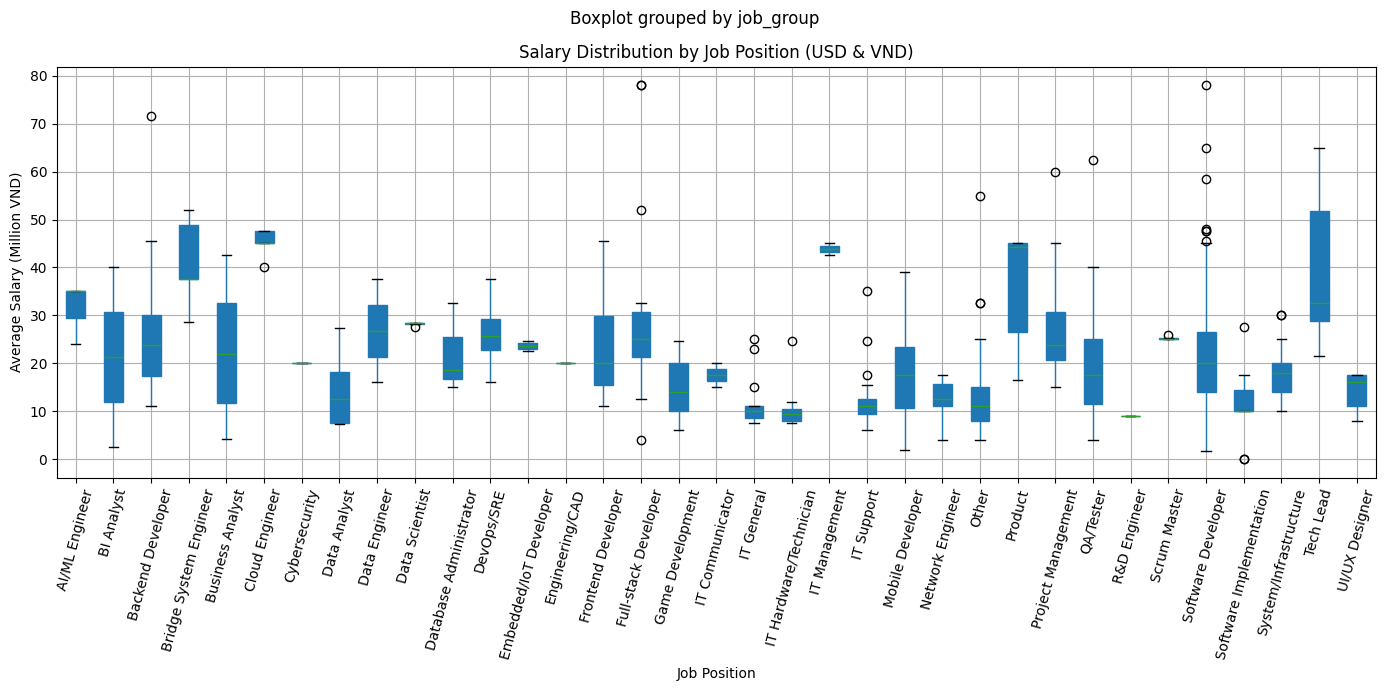

In [113]:
combined_salary_df.boxplot(column="avg_salary_in_million_VND", by="job_group", rot=75, figsize=(14,7), patch_artist=True)
plt.title("Salary Distribution by Job Position (USD & VND)")
plt.xlabel("Job Position")
plt.ylabel("Average Salary (Million VND)")
plt.tight_layout()
plt.show()

### Analysis 2: Job distribution heatmap

In [114]:
combined_salary_df[["city", "district"]]

,city,district
0,Hà Nội,None
1,Hồ Chí Minh,None
6,Hà Nội,Nam Từ Liêm
8,Hà Nội,Cầu Giấy
10,Hà Nội,Cầu Giấy
...,...,...
2195,Hà Nội,Hà Đông
2196,Hà Nội,Hai Bà Trưng
2198,Hà Nội,Đống Đa
2199,Hà Nội,Thạch Thất


In [115]:
location_counts = (
    df.groupby(["city", "district"])
      .size()
      .reset_index(name="job_count")
)

location_counts.head()

,city,district,job_count
0,Bình Dương,Bến Cát,1
1,Bình Dương,Dĩ An,4
2,Bình Dương,Thuận An,4
3,Bình Dương,Thủ Dầu Một,7
4,Bình Dương,Tân Uyên,2


In [116]:
heatmap_data = location_counts.pivot_table(
    index="district",
    columns="city",
    values="job_count",
    fill_value=0
)

heatmap_data.head()

city,Bình Dương,Bình Định,Bắc Giang,Bắc Ninh,Bến Tre,Cần Thơ,Gia Lai,Hoà Bình,Hà Nam,Hà Nội,...,Lâm Đồng,Nghệ An,Thanh Hoá,Thái Bình,Thừa Thiên Huế,Tây Ninh,Vĩnh Phúc,Đà Nẵng,Đồng Nai,Đồng Tháp
district,,,,,,,,,,,,,,,,,,,,,
An Dương,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Ba Vì,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Ba Đình,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,55.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Biên Hoà,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,0.0
Bình Chánh,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


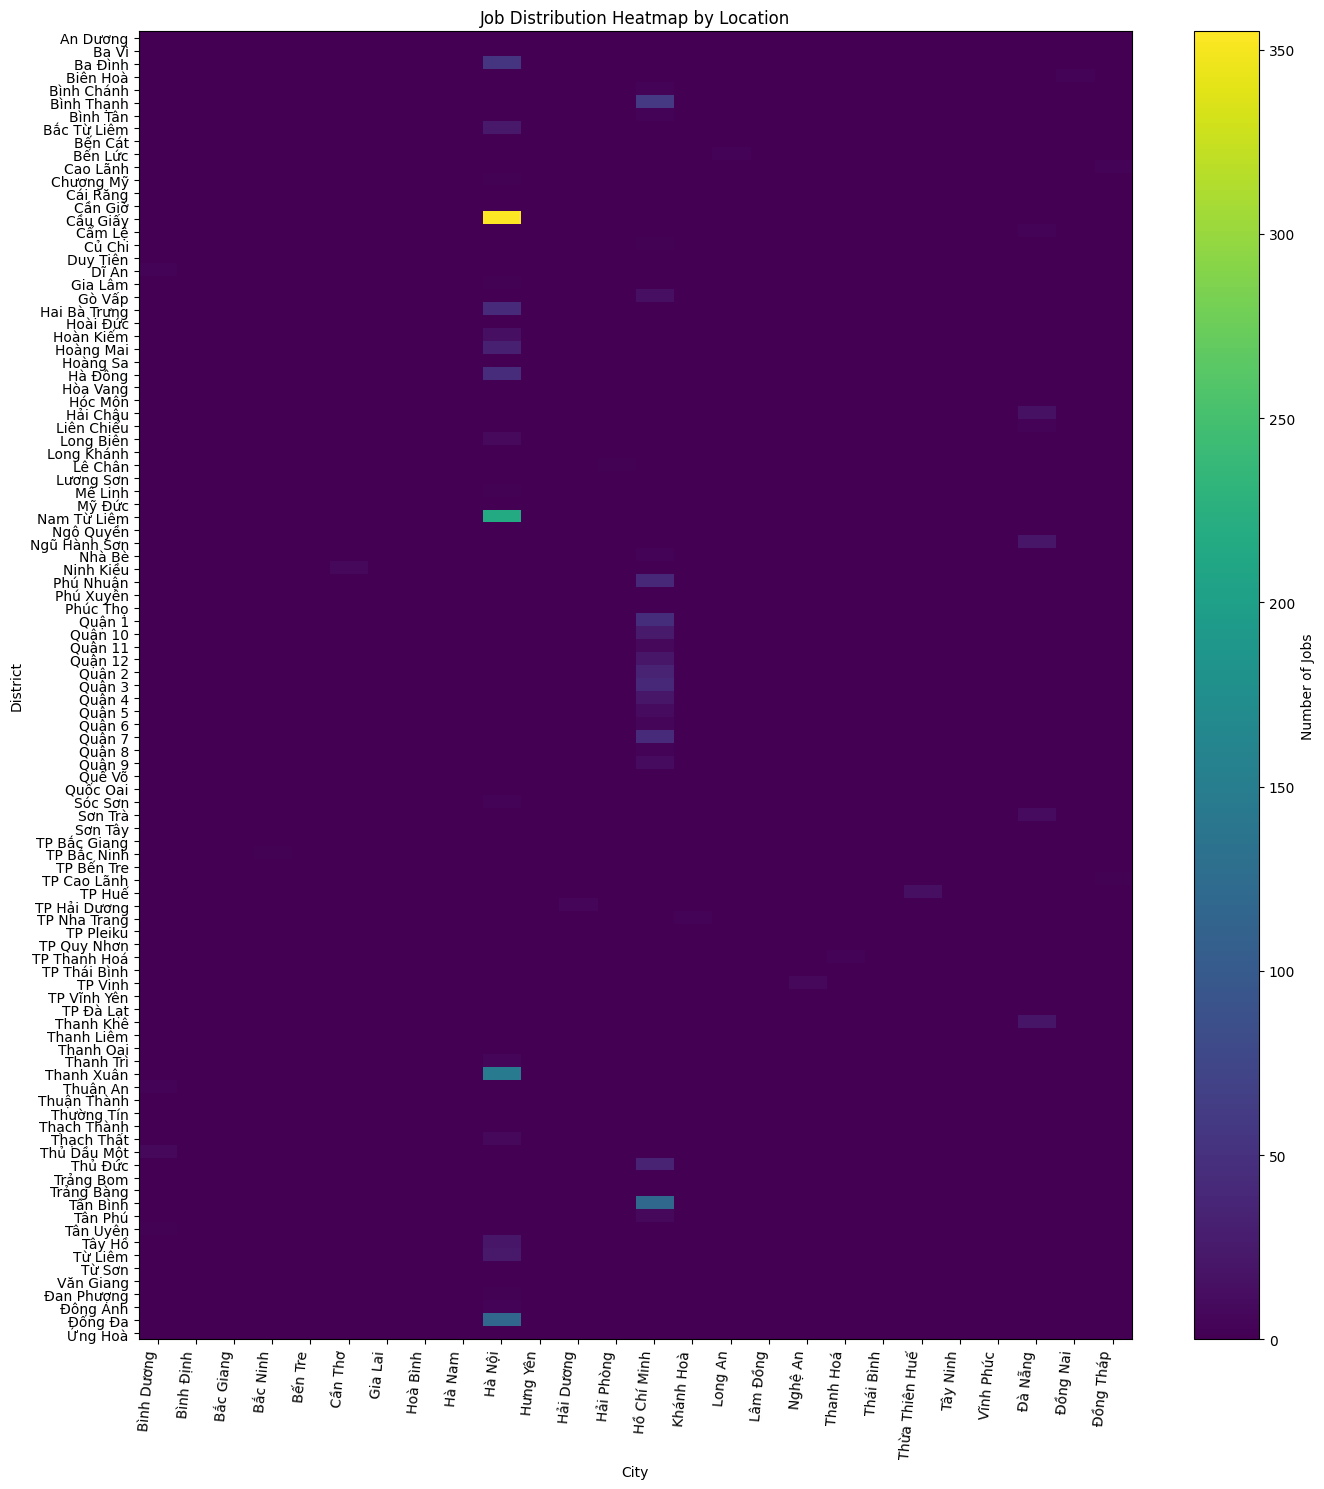

In [117]:
plt.figure(figsize=(14, 15))

plt.imshow(
    heatmap_data,
    aspect="auto"
)

plt.colorbar(label="Number of Jobs")

plt.xticks(
    range(len(heatmap_data.columns)),
    heatmap_data.columns,
    rotation=85,
    ha="right"
)

plt.yticks(
    range(len(heatmap_data.index)),
    heatmap_data.index
)

plt.title("Job Distribution Heatmap by Location")
plt.xlabel("City")
plt.ylabel("District")

plt.tight_layout()
plt.show()

### Analysis 3: Hot Technology Trend

In [118]:
technologies = {
    "Python": r"\bpython\b",
    "Java": r"\bjava\b",
    "JavaScript": r"\bjavascript\b",
    "React": r"\breact\b",
    "Angular": r"\bangular\b",
    "Vue": r"\bvue\b",
    "Node.js": r"\bnode\.?js\b",
    ".NET": r"\.net\b",
    "PHP": r"\bphp\b",
    "Flutter": r"\bflutter\b",
    "AWS": r"\baws\b",
    "Azure": r"\bazure\b",
    "Docker": r"\bdocker\b",
    "Kubernetes": r"\bkubernetes\b",
    "SQL": r"\bsql\b"
}

In [119]:
technology_counts = {}

titles = df["job_title"].fillna("")

for technology, pattern in technologies.items():
    technology_counts[technology] = (
        titles
        .str.contains(
            pattern,
            case=False,
            regex=True
        )
        .sum()
    )

technology_df = (
    pd.DataFrame(
        technology_counts.items(),
        columns=["technology", "job_count"]
    )
    .sort_values(
        "job_count",
        ascending=False
    )
)

technology_df

,technology,job_count
7,.NET,191
1,Java,153
8,PHP,77
6,Node.js,56
0,Python,48
3,React,40
9,Flutter,31
2,JavaScript,28
4,Angular,20
14,SQL,15


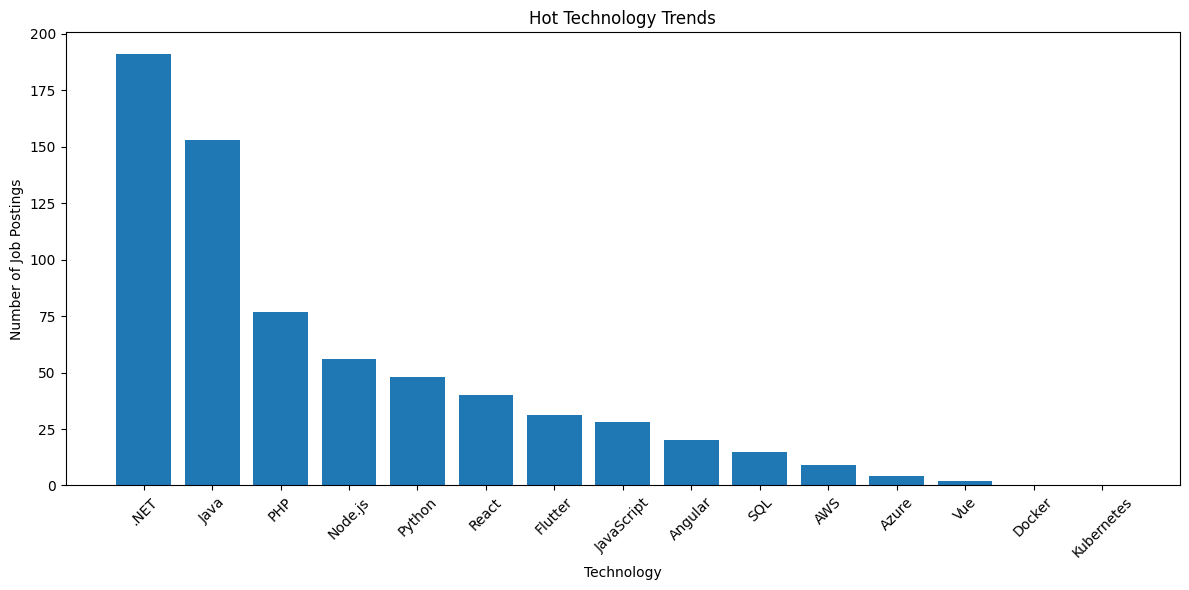

In [120]:
plt.figure(figsize=(12, 6))

plt.bar(
    technology_df["technology"],
    technology_df["job_count"]
)

plt.title("Hot Technology Trends")
plt.xlabel("Technology")
plt.ylabel("Number of Job Postings")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [ ]:
# engine.dispose()